# Ekstraksi EMNIST ByClass (Train) ke Gambo_EMNIST

Notebook ini mengekstrak gambar huruf dari `emnist-byclass-train.csv` lalu menyalinnya ke folder
`Gambo_EMNIST/Train/Normal` dan `Gambo_EMNIST/Test/Normal` dengan:

- **Hanya alfabet** (A-Z, a-z) — digit 0-9 dibuang
- **Split 80:20** per huruf (Train:Test) untuk mencegah data leakage
- **Penamaan** melanjutkan index terakhir yang sudah ada di folder tujuan
- **Format nama file:** `{Huruf}-{index}.png`
- **Seed acak tetap** (42) agar reprodusibel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import re
import random
from collections import defaultdict

random.seed(42)
np.random.seed(42)

## 1. Load Mapping Label (ASCII)

In [2]:
mapping_path = 'Dataset/emnist-byclass-mapping.txt'
df_mapping = pd.read_csv(mapping_path, sep=' ', header=None, names=['label', 'ascii_code'])

label_to_ascii = dict(zip(df_mapping['label'], df_mapping['ascii_code']))
label_to_char = {k: chr(v) for k, v in label_to_ascii.items()}

# Filter: hanya alfabet (label 10-61, ASCII 65-90 dan 97-122)
alpha_labels = {k: v for k, v in label_to_char.items() if v.isalpha()}

print(f'Total kelas dalam mapping: {len(label_to_char)}')
print(f'Kelas alfabet saja: {len(alpha_labels)}')
print(f'Kelas digit (dibuang): {len(label_to_char) - len(alpha_labels)}')
print()
print('Contoh mapping alfabet:')
for k, v in list(alpha_labels.items())[:5]:
    print(f'  Label {k} -> "{v}"')

Total kelas dalam mapping: 62
Kelas alfabet saja: 52
Kelas digit (dibuang): 10

Contoh mapping alfabet:
  Label 10 -> "A"
  Label 11 -> "B"
  Label 12 -> "C"
  Label 13 -> "D"
  Label 14 -> "E"


## 2. Load CSV EMNIST ByClass (Test Only)

Kita hanya menggunakan `emnist-byclass-train.csv` (~116k gambar).
File `train.csv` terlalu besar dan tidak diperlukan.

In [3]:
csv_path = 'Dataset/emnist-byclass-train.csv'

print(f'Loading {csv_path}...')
df = pd.read_csv(csv_path, header=None, dtype=np.uint8)
print(f'Shape: {df.shape}  ({df.shape[0]:,} gambar, {df.shape[1]} kolom)')

# Kolom 0 = label, kolom 1-784 = piksel
labels = df.iloc[:, 0].values
pixels = df.iloc[:, 1:].values

del df
print('DataFrame dihapus dari RAM.')

Loading Dataset/emnist-byclass-train.csv...
Shape: (697932, 785)  (697,932 gambar, 785 kolom)
DataFrame dihapus dari RAM.


## 3. Filter Hanya Alfabet (Buang Digit 0-9)

In [4]:
alpha_label_set = set(alpha_labels.keys())
mask = np.isin(labels, list(alpha_label_set))

alpha_labels_arr = labels[mask]
alpha_pixels = pixels[mask]

print(f'Total gambar sebelum filter: {len(labels):,}')
print(f'Total gambar setelah filter (alfabet saja): {len(alpha_labels_arr):,}')
print(f'Gambar digit yang dibuang: {len(labels) - len(alpha_labels_arr):,}')

# Bebaskan memori
del labels, pixels, mask

Total gambar sebelum filter: 697,932
Total gambar setelah filter (alfabet saja): 352,897
Gambar digit yang dibuang: 345,035


## 4. Visualisasi Sample (Verifikasi Orientasi)

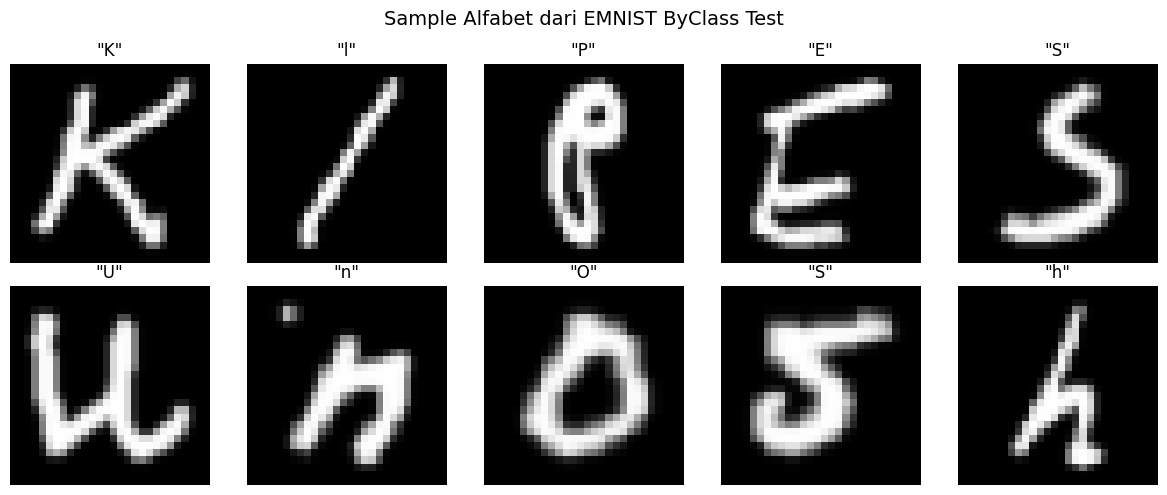

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Alfabet dari EMNIST ByClass Test', fontsize=14)

indices = np.random.choice(len(alpha_labels_arr), 10, replace=False)
for i, ax in enumerate(axes.flatten()):
    idx = indices[i]
    # EMNIST: perlu transpose karena column-major
    img = alpha_pixels[idx].reshape(28, 28).T
    ax.imshow(img, cmap='gray')
    char = label_to_char[int(alpha_labels_arr[idx])]
    ax.set_title(f'"{char}"')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Konfigurasi Path & Scan Index Terakhir

Memindai file yang sudah ada di `Gambo_EMNIST` untuk menentukan index awal penamaan.

In [6]:
BASE = 'Dataset'
TRAIN_DST = os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Normal')
TEST_DST = os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Normal')
SPLIT_RATIO = 0.8

def get_max_index_per_letter(folder):
    max_idx = defaultdict(int)
    if not os.path.exists(folder):
        return max_idx
    for f in os.listdir(folder):
        m = re.match(r'^([A-Za-z])[-_](\d+)\.png$', f)
        if m:
            letter = m.group(1)
            idx = int(m.group(2))
            if idx > max_idx[letter]:
                max_idx[letter] = idx
    return max_idx

train_max = get_max_index_per_letter(TRAIN_DST)
test_max = get_max_index_per_letter(TEST_DST)

before_train = len(os.listdir(TRAIN_DST)) if os.path.exists(TRAIN_DST) else 0
before_test = len(os.listdir(TEST_DST)) if os.path.exists(TEST_DST) else 0

print(f'Train/Normal saat ini: {before_train:,} file')
print(f'Test/Normal saat ini:  {before_test:,} file')
print(f'Huruf terlacak di Train: {len(train_max)}')
print(f'Huruf terlacak di Test:  {len(test_max)}')

Train/Normal saat ini: 39,334 file
Test/Normal saat ini:  19,557 file
Huruf terlacak di Train: 15
Huruf terlacak di Test:  27


## 6. Ekstrak & Simpan ke Gambo_EMNIST

Untuk setiap huruf:
1. Kumpulkan semua piksel gambar huruf tersebut
2. Shuffle secara deterministik
3. Split 80% Train / 20% Test
4. Reshape 28x28, transpose, simpan sebagai PNG
5. Penamaan melanjutkan index terakhir

In [7]:
os.makedirs(TRAIN_DST, exist_ok=True)
os.makedirs(TEST_DST, exist_ok=True)

total_train = 0
total_test = 0

# Proses per huruf
unique_labels = sorted(set(alpha_labels_arr))

for label_id in unique_labels:
    char = label_to_char[int(label_id)]
    
    # Ambil semua gambar untuk huruf ini
    mask = alpha_labels_arr == label_id
    char_pixels = alpha_pixels[mask]
    
    # Shuffle indices
    indices = list(range(len(char_pixels)))
    random.shuffle(indices)
    
    # Split 80:20
    split_idx = int(len(indices) * SPLIT_RATIO)
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    # Index awal
    train_start = train_max.get(char, 0) + 1
    test_start = test_max.get(char, 0) + 1
    
    # Simpan Train
    for i, idx in enumerate(train_indices):
        img = char_pixels[idx].reshape(28, 28).T
        img_pil = Image.fromarray(img, mode='L')
        fname = f'{char}-{train_start + i}.png'
        img_pil.save(os.path.join(TRAIN_DST, fname))
    
    if train_indices:
        train_max[char] = train_start + len(train_indices) - 1
    
    # Simpan Test
    for i, idx in enumerate(test_indices):
        img = char_pixels[idx].reshape(28, 28).T
        img_pil = Image.fromarray(img, mode='L')
        fname = f'{char}-{test_start + i}.png'
        img_pil.save(os.path.join(TEST_DST, fname))
    
    if test_indices:
        test_max[char] = test_start + len(test_indices) - 1
    
    total_train += len(train_indices)
    total_test += len(test_indices)
    
    print(
        f'  "{char}": {len(char_pixels):,} gambar -> '
        f'Train +{len(train_indices)} (idx {train_start}-{train_max[char]}), '
        f'Test +{len(test_indices)} (idx {test_start}-{test_max[char]})'
    )

print(f'\nTotal EMNIST disimpan ke Train/Normal: {total_train:,}')
print(f'Total EMNIST disimpan ke Test/Normal:  {total_test:,}')

  "A": 6,407 gambar -> Train +5125 (idx 2501-7625), Test +1282 (idx 524-1805)
  "B": 3,878 gambar -> Train +3102 (idx 2501-5602), Test +776 (idx 492-1267)
  "C": 10,094 gambar -> Train +8075 (idx 2501-10575), Test +2019 (idx 508-2526)
  "D": 4,562 gambar -> Train +3649 (idx 2501-6149), Test +913 (idx 539-1451)
  "E": 4,934 gambar -> Train +3947 (idx 2499-6445), Test +987 (idx 503-1489)
  "F": 9,182 gambar -> Train +7345 (idx 1162-8506), Test +1837 (idx 224-2060)
  "G": 2,517 gambar -> Train +2013 (idx 2501-4513), Test +504 (idx 541-1044)
  "H": 3,152 gambar -> Train +2521 (idx 2498-5018), Test +631 (idx 522-1152)
  "I": 11,946 gambar -> Train +9556 (idx 1119-10674), Test +2390 (idx 276-2665)
  "J": 3,762 gambar -> Train +3009 (idx 3003-6011), Test +753 (idx 615-1367)
  "K": 2,468 gambar -> Train +1974 (idx 2501-4474), Test +494 (idx 499-992)
  "L": 5,076 gambar -> Train +4060 (idx 2500-6559), Test +1016 (idx 498-1513)
  "M": 9,002 gambar -> Train +7201 (idx 2501-9701), Test +1801 (idx 

## 7. Verifikasi & Laporan Akhir

In [8]:
after_train = len(os.listdir(TRAIN_DST))
after_test = len(os.listdir(TEST_DST))

print('=' * 55)
print('LAPORAN AKHIR')
print('=' * 55)
print(f'\nTrain/Normal: {before_train:,} -> {after_train:,} (+{after_train - before_train:,})')
print(f'Test/Normal:  {before_test:,} -> {after_test:,} (+{after_test - before_test:,})')
print(f'\nTotal Normal (Train+Test): {after_train + after_test:,}')

# Cek keseimbangan kelas
train_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Corrected')))
train_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Reversal')))
test_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Corrected')))
test_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Reversal')))

total_normal = after_train + after_test
total_dyslexia = train_corr + train_rev + test_corr + test_rev

print(f'\n--- Keseimbangan Kelas ---')
print(f'Total Normal (0):   {total_normal:,}')
print(f'Total Dyslexia (1): {total_dyslexia:,} (Corrected: {train_corr+test_corr:,}, Reversal: {train_rev+test_rev:,})')

if total_normal > 0:
    ratio = total_dyslexia / total_normal
    print(f'Rasio Normal:Dyslexia = 1:{ratio:.2f}')
    if 0.8 <= ratio <= 1.2:
        print('Status: SEIMBANG')
    elif ratio > 1.2:
        print(f'Status: Dyslexia masih lebih banyak ({(ratio-1)*100:.0f}% lebih)')
    else:
        print(f'Status: Normal sudah lebih banyak')

LAPORAN AKHIR

Train/Normal: 39,334 -> 239,412 (+200,078)
Test/Normal:  19,557 -> 69,132 (+49,575)

Total Normal (Train+Test): 308,544

--- Keseimbangan Kelas ---
Total Normal (0):   308,544
Total Dyslexia (1): 149,481 (Corrected: 84,818, Reversal: 64,663)
Rasio Normal:Dyslexia = 1:0.48
Status: Normal sudah lebih banyak


## 8. Balancing: Pangkas EMNIST Berlebih

Normal terlalu banyak. Kita hapus file EMNIST yang berlebih agar rasio Normal:Dyslexia mendekati 1:1.
Strategi: hapus dari huruf yang jumlahnya paling banyak terlebih dahulu.

In [9]:
import os, re, random
from collections import defaultdict

random.seed(42)

BASE = 'Dataset'
TRAIN_N = os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Normal')
TEST_N = os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Normal')

# Hitung total Dyslexia
train_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Corrected')))
train_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Reversal')))
test_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Corrected')))
test_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Reversal')))
total_dyslexia = train_corr + train_rev + test_corr + test_rev

total_normal_now = len(os.listdir(TRAIN_N)) + len(os.listdir(TEST_N))
to_remove = total_normal_now - total_dyslexia

print(f'Normal saat ini:  {total_normal_now:,}')
print(f'Dyslexia target:  {total_dyslexia:,}')
print(f'Harus dihapus:    {to_remove:,} file Normal')

if to_remove <= 0:
    print('Sudah seimbang. Tidak perlu hapus.')
else:
    # Kumpulkan file EMNIST (format: Huruf-index.png)
    # File Gambo asli pakai underscore (d_3620.png)
    emnist_files = []
    for folder in [TRAIN_N, TEST_N]:
        for f in os.listdir(folder):
            m = re.match(r'^([A-Za-z])-(\d+)\.png$', f)
            if m:
                letter = m.group(1)
                idx = int(m.group(2))
                emnist_files.append((os.path.join(folder, f), letter, idx))

    print(f'Total file EMNIST terdeteksi: {len(emnist_files):,}')

    # Hitung per huruf
    letter_counts = defaultdict(list)
    for path, letter, idx in emnist_files:
        letter_counts[letter].append((path, idx))

    sorted_letters = sorted(letter_counts.keys(),
                            key=lambda l: len(letter_counts[l]), reverse=True)

    print('\nDistribusi per huruf (top 10):')
    for l in sorted_letters[:10]:
        print(f'  {l}: {len(letter_counts[l]):,}')

    # Binary search cap per huruf
    total_emnist = len(emnist_files)
    target_emnist = total_emnist - to_remove

    lo, hi = 0, max(len(letter_counts[l]) for l in sorted_letters)
    while lo < hi:
        mid = (lo + hi) // 2
        kept = sum(min(len(letter_counts[l]), mid) for l in sorted_letters)
        if kept < target_emnist:
            lo = mid + 1
        else:
            hi = mid
    cap = lo

    print(f'\nCap per huruf: {cap}')
    print(f'Target EMNIST dipertahankan: {target_emnist:,}')

    # Hapus file melebihi cap (index terbesar dihapus duluan)
    deleted = 0
    for letter in sorted_letters:
        files_for_letter = letter_counts[letter]
        if len(files_for_letter) <= cap:
            continue
        files_for_letter.sort(key=lambda x: x[1], reverse=True)
        excess = files_for_letter[:len(files_for_letter) - cap]
        for path, idx in excess:
            os.remove(path)
            deleted += 1
        print(f'  {letter}: {len(files_for_letter):,} -> {cap} (hapus {len(excess)})')

    print(f'\nTotal file dihapus: {deleted:,}')

    # Verifikasi
    final_train = len(os.listdir(TRAIN_N))
    final_test = len(os.listdir(TEST_N))
    final_normal = final_train + final_test

    print(f'\n--- Hasil Akhir ---')
    print(f'Train/Normal: {final_train:,}')
    print(f'Test/Normal:  {final_test:,}')
    print(f'Total Normal: {final_normal:,}')
    print(f'Total Dyslexia: {total_dyslexia:,}')
    ratio = total_dyslexia / final_normal if final_normal > 0 else 0
    print(f'Rasio Normal:Dyslexia = 1:{ratio:.2f}')

Normal saat ini:  308,544
Dyslexia target:  149,481
Harus dihapus:    159,063 file Normal
Total file EMNIST terdeteksi: 285,643

Distribusi per huruf (top 10):
  O: 25,483
  S: 21,166
  e: 17,205
  U: 13,598
  I: 13,065
  C: 12,594
  M: 11,424
  N: 10,647
  T: 10,318
  F: 10,224

Cap per huruf: 3778
Target EMNIST dipertahankan: 126,580
  O: 25,483 -> 3778 (hapus 21705)
  S: 21,166 -> 3778 (hapus 17388)
  e: 17,205 -> 3778 (hapus 13427)
  U: 13,598 -> 3778 (hapus 9820)
  I: 13,065 -> 3778 (hapus 9287)
  C: 12,594 -> 3778 (hapus 8816)
  M: 11,424 -> 3778 (hapus 7646)
  N: 10,647 -> 3778 (hapus 6869)
  T: 10,318 -> 3778 (hapus 6540)
  F: 10,224 -> 3778 (hapus 6446)
  P: 8,806 -> 3778 (hapus 5028)
  r: 8,579 -> 3778 (hapus 4801)
  A: 8,442 -> 3778 (hapus 4664)
  t: 7,945 -> 3778 (hapus 4167)
  l: 7,884 -> 3778 (hapus 4106)
  d: 7,648 -> 3778 (hapus 3870)
  L: 7,435 -> 3778 (hapus 3657)
  E: 7,426 -> 3778 (hapus 3648)
  D: 6,699 -> 3778 (hapus 2921)
  B: 6,217 -> 3778 (hapus 2439)
  J: 6,16